<font size='4'>In this file we introduce the luminosity distance expansions in terms of the redshift variables z, y, log(1+z), plus Pade polynomials 21, 22, 32, 42, 51 and the Eis series.

<font size='5'>Jess report:

- Unique minimizer for z, y and log series.
- I have kept the order outside, so it is not minimized as a parameter of course, but I don't know how to predefine Ω_k. If I put it inside the function, then how can I change it when minimizing?

<font size='5'><span style="color:red">
Extras:

Change z distribution to something like Pantheon+



</font>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.cosmology import Planck15
import astropy.cosmology as cosmo
import astropy.units as u
from scipy.optimize import minimize

In [2]:
# Parameters and redshift space for generating the mock data

H0 =  73.8
Om = 0.3
Ok = 0.0
w = -1.0

zs = np.linspace(0.001, 5, 100)
zs = zs[1:] # We don't want z = 0

my_cosmo = cosmo.wCDM(H0=H0, Om0=Om, Ode0=1.0-Om-Ok)
dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value
ys = zs/(1+zs)

# Series expansions: z, y, log and Pade

In [3]:
def to_cosmographic(H0, Om, Ok, w):
    q0 = 1.0/2.0 *(1.0-Ok-3.0*(-1.0+Om+Ok)*w)
    j0 = 1 - Ok + (9/2)*(1.0-Om-Ok)*w*(1+w)
    s0 = -7/2 + 4*Ok -Ok**2/2 + (-81/4 + 15*Ok/4)*(1-Ok-Om)*w + (9*Ok/4 -117/4 -27*(1-Ok-Om)/4)*(1-Ok-Om)*w**2 -(27/4)*(3-Ok -Om)*(1-Ok-Om)*w**3
    c0 = 35/2 -23*Ok +11*Ok**2/2 +(489/4 -189*Ok/4)*(1-Ok-Om)*w +(207 + 189*(1-Ok -Om)/2 -99*Ok/2)*(1-Ok-Om)*w**2 +(621/4 + 162*(1- Ok - Om) -81/4*Ok)*(1- Ok - Om)*w**3 +81/2 *(1+2*(1-Ok -Om))*(1-Ok-Om)*w**4
    p0 = 1/4*(-455 +681*Ok -237*Ok**2 +11*Ok**3) +(-7407/8 +2187*Ok/4 -255*Ok**2/8)*(1.0-Om-Ok)*w \
         +(-6849/4 + 1449*Ok/2 -99*Ok**2/4 -9315*(1.0-Om-Ok)/8 +945*Ok*(1.0-Om-Ok)/8)*(1.0-Om-Ok)*w**2 \
         +(-13041/8 +1971*Ok/4 -81*Ok**2/8 -5103*(1.0-Om-Ok)/2 +621*Ok*(1.0-Om-Ok)/4 -567*(1.0-Om-Ok)*(1.0-Om-Ok)/4)*(1.0-Om-Ok)*w**3 \
         +(-729 +243*Ok/2 -17577*(1.0-Om-Ok)/8 +567*Ok*(1.0-Om-Ok)/8 -243*(1.0-Om-Ok)*(1.0-Om-Ok))*(1.0-Om-Ok)*w**4 \
         -243/4*(2+11*(1.0-Om-Ok)+2*(1.0-Om-Ok)*(1.0-Om-Ok))*(1.0-Om-Ok)*w**5
    return H0, q0, j0, s0, c0, p0

In [4]:
def redshift_expansion(z, H0, a0, a1, a2, a3, a4, a5, order):
    if order == 0:
        return 300000 * z / H0 * (a0)
    elif order == 1:
        return 300000 * z / H0 * (a0 + a1*z)
    elif order == 2:
        return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0)
    elif order == 3:
        return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0 + a3 * z**3.0)
    elif order == 4:
        return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0 + a3 * z**3.0 + a4 * z**4.0)
    elif order == 5:
        return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0 + a3 * z**3.0 + a4 * z**4.0 + a5 * z**5.0)


def z_series(z, H0, q0, j0, s0, c0, p0, Ok, order=3):
    a0 = 1.0
    a1 = 1.0/2.0 - q0/2.0
    a2 = -1.0/6.0 - j0/6.0 + q0/6.0 + q0**2.0 / 2.0 + Ok/6.
    a3 = 1.0/12.0 + 5 * j0 / 24.0 - q0/12.0 + 5.0*j0*q0/12.0  \
        -5.0 * q0**2.0 / 8.0  -5.0 * q0**3.0 / 8.0 + s0/24.0 -Ok/12. -Ok*q0/4.
    a4 = -1.0/20.0 - 9*j0/40.0 +j0**2/12.0 -c0/120.0 +q0/20.0 \
        -11*j0*q0/12.0 +27*q0**2/40.0 -7*j0*q0**2/8.0 \
        + 11*q0**3/8.0 + 7*q0**4/8 - 11*s0/120- q0*s0/8.0 -Ok**2 -5*Ok*(2*j0 - 9*q0**2 -8*q0 -1)
    a5 = 1.0/30.0 + 7*j0/30.0 - 19.0*j0**2/72 + 19.0*c0/720.0 \
         +p0/720 -q0/30.0 +13*j0*q0/9 -7*j0**2*q0/18.0 +7*c0*q0/240.0 \
         -7*q0**2.0/10.0 +133.0*j0*q0**2.0/48.0 -13.0*q0**3.0/6.0 \
         +7.0*j0*q0**3.0/4.0 -133.0*q0**4.0/48.0 -21.0*q0**5.0/16.0  \
         +13.0*s0/90.0 -7.0*j0*s0/144.0 +19.0*q0*s0/48.0 +7*q0**2.0*s0/24 \
         -15.*Ok*(-14*j0*q0 -9*j0 +28*q0**3 +40*q0**2 +17*q0 -s0 +1) \
         -Ok**2 * (15*q0 +9)

    return redshift_expansion(z, H0, a0, a1, a2, a3, a4, a5, order)



def y_series(y, H0, q0, j0, s0, c0, p0, Ok, order=3):

    a0 = 1.0
    a1 = -1/2*(q0-3)
    a2 = 1/6 * (11-5*q0+3*q0**2-j0 +Ok)
    a3 = 1/24 * (50 - 7*j0 -26*q0+10*q0*j0+21*q0**2-15*q0**3+s0 +10*Ok -6*q0*Ok)
    a4 = 1/120* ( 274 + 10*j0**2 -c0 - 154*q0 + 141*q0**2 -135*q0**3 +105*q0**4 + 9*s0 \
                 -15*q0*s0 +85*Ok -80*q0*Ok +45*q0**2*Ok + Ok**2 \
                 -j0*(47 - 90*q0 + 105*q0**2 + 10*Ok))
    a5 = 1/720 * (1764 + p0 + j0**2 * (110 - 280*q0) - 1044*q0 + 1026*q0**2 - 1110*q0**3 \
        +1155*q0**4 - 945*q0**5 + c0*(-11 + 21*q0) + 74*s0 - 165*q0*s0 + 210*q0**2*s0 \
        +735*Ok - 855*q0*Ok + 750*q0**2 *Ok - 420*q0**3 *Ok + 15*s0*Ok + 21*Ok**2 \
        -15*q0*Ok**2 + j0*(-342 - 1155*q0**2 + 1260*q0**3 - 35*s0 - 165*Ok + 10*q0*(74 + 21*Ok)))

    return redshift_expansion(y, H0, a0, a1, a2, a3, a4, a5, order)



def log_series(log1z, H0, q0, j0, s0, c0, p0, Ok, order=3):
    a0 = 1.0
    a1 = 1 -1/2*q0
    a2 = 1/6 * (3-2*q0+3*q0**2-j0 +Ok)
    a3 =  1/6 +(1/8)*(-q0 + q0**2 -5*q0**3) +(5/12)*q0*j0 + 1/24*(-j0 + s0 +4*Ok - 6*q0*Ok)
    a4 = 1/120 * (5 + 10*j0**2 - c0 - 4*q0 + 6*q0**2 + 15*q0**3 + 105*q0**4 - s0 -15*q0*s0 \
         + 10*Ok - 20*q0*Ok +45*q0**2 *Ok + Ok**2 -j0*(2 + 10*q0 + 105*q0**2 + 10*Ok)  )
    a5 = 1/720 * (6 + p0 - 5*q0 + 6*q0**2 - 60*q0**3 - 420*q0**4 - 945*q0**5 -40*j0**2 *(1 + 7*q0) \
         + c0*(4 + 21*q0) + 4*s0 + 60*q0*s0 +210*q0**2*s0 + 20*Ok - 45*q0*Ok +75*q0**2*Ok \
         - 420*q0**3 *Ok + 15*s0*Ok + 6*Ok**2 -15*q0*Ok**2 +j0*(-2 + 420*q0**2 + 1260*q0**3 - 35*s0 \
         - 15*Ok + 10*q0*(4 + 21*Ok)) )

    return redshift_expansion(log1z, H0, a0, a1, a2, a3, a4, a5, order)

In [69]:
def dLpade22(z,H0, q0, j0, s0, c0, p0, Ok, order =0):
    numerator = 6*z*(j0*((6*q0+9)*z+4) - q0*(2*Ok*z+19*z+16)-6*Ok*z-4*Ok-6*q0**3*z\
                     -2*q0**2*(7*z+3)+s0*z+9*z+10)
    denominator = (4*j0**2*z**2 + j0*(z**2*(-8*Ok+6*q0**2-23*q0-7)+6*(8*q0+7)*z+24)\
                    +4*Ok**2*z**2+q0**2*((6*Ok+19)*z**2-114*z-36)+q0*(z**2*(20*Ok+3*s0+4)\
                    -12*(2*Ok+3)*z-96)-2*Ok*z**2-24*Ok*z-24*Ok-9*q0**4*z**2+6*q0**3*z*(4*z-9)\
                    -3*s0*z**2+6*s0*z-2*z**2+24*z+60)

    P22_value =  (300000/H0)*(numerator / (denominator ) )
    return P22_value

def lkl_pade22(pars,z,data):
    y=data
    x=dLpade22(z,*pars)
    return np.sum((y-x)**2)

In [68]:
def dLpade21(z,H0, q0, j0, s0, c0, p0, Ok, order =0):
    numerator = z*(z*(-2*j0 + 2*Ok - 5) + 3*q0**2*z + q0*(8*z + 6) - 6)
    denominator = 2*(z*(-j0 + Ok - 1) + 3*q0**2*z + q0*(z + 3) - 3)


    P21_value =  (300000/H0)*(numerator / (denominator ) )
    return P21_value

def lkl_pade21(pars,z,data):
    y=data
    x=dLpade21(z,*pars)
    return np.sum((y-x)**2)

In [70]:
def dLpade32(z,H0, q0, j0, s0, c0, p0, Ok, order =0):
    numerator = z*(-135*z**2*q0**6-270*z*(4*z+3)*q0**5-9*((30*Ok-63)*z**2-50*z+60)*q0**4+2*((887-90*Ok)*z**2\
                  +3*(30*Ok+589)*z+720)*q0**3+6*((-3*Ok**2+128*Ok+3*c0+58*s0+125)*z**2+5*(46*Ok+9*s0+67)*z\
                  +60*Ok+190)*q0**2+6*(2*(16*Ok**2+44*Ok+4*c0+9)*z**2+ (34*Ok**2+300*Ok+6*c0+62)*z+40*(5*Ok+1)\
                  +s0*((10*Ok-17)*z**2-4*z+30))*q0+240*Ok**2+80*j0**3*z**2+28*Ok**3*z**2+30*Ok**2*z**2+15*s0**2*z**2\
                  -30*c0*z**2+12*c0*Ok*z**2-18*Ok*z**2+12*Ok*s0*z**2-210*s0*z**2-40*z**2-120*Ok-180*s0+276*Ok**2*z\
                  -36*c0*z-120*Ok*z-60*Ok*s0*z-426*s0*z-156*z-3*j0**2*( (60*q0**2-40*q0+40*Ok-177)*z**2-20*(2*q0+13)*z\
                  -80)+6*j0*(45*z**2*q0**4+5*z*(41*z+30)*q0**3+ ((70*Ok-207)*z**2-225*z+60)*q0**2+2*((5*s0-136)*z**2\
                  -2*(15*Ok+137)*z-115)*q0+ (2*Ok**2-66*Ok-2*c0+13*s0-47)*z**2-10*(8*Ok+7)+(-170*Ok+10*s0-127)*z)-120)
    denominator = 3*(-135*z**2*q0**6-30*z*(5*z+12)*q0**5-3*((20*Ok-71)*z**2-160*z+60)*q0**4+6*((-20*Ok+5*s0+44)*z**2\
                  +4*(5*Ok+47)*z+80)*q0**3+2*( (-6*Ok**2+28*Ok+6*c0+21*s0+46)*z**2+20*(15*Ok+3*s0+13)*z+60*Ok+190)*q0**2\
                  +4*( (-11*Ok**2+9*Ok+c0+2)*z**2+(27*Ok**2+95*Ok+3*c0+16)*z+20*(5*Ok+1)+s0*(-9*z**2-17*z+15))*q0+80*Ok**2\
                  +40*j0**3*z**2-4*Ok**3*z**2+4*Ok**2*z**2+5*s0**2*z**2-4*c0*z**2+4*c0*Ok*z**2+4*Ok*z**2+24*Ok*s0*z**2\
                  -24*s0*z**2-4*z**2-40*Ok-60*s0+52*Ok**2*z-12*c0*z-20*Ok*z-20*Ok*s0*z-112*s0*z-32*z+j0**2*( (-40*q0**2\
                  +20*q0-80*Ok+57)*z**2+20*(4*q0+11)*z+80)+2*j0* (90*z**2*q0**4+15*z*(5*z+12)*q0**3+ (3*(20*Ok-47)*z**2-370*z
                  +60)*q0**2+2*((35*Ok+10*s0-52)*z**2-2*(25*Ok+117)*z-115)*q0+ (22*Ok**2-6*Ok-2*c0+3*s0-16)*z**2-10*(8*Ok+7)\
                  +2*(-65*Ok+5*s0-46)*z)-40)

    P32_value =  (300000/H0)*(numerator / (denominator ) )

    return P32_value

In [79]:
def dLpadeaverage(z,H0, q0, j0, s0, c0, p0, Ok, order =0):
    return (dLpade32(z,H0, q0, j0, s0, c0, p0, Ok) + dLpade21(z,H0, q0, j0, s0, c0, p0, Ok))/2

In [42]:
def dLpade42(z,H0, q0, j0, s0, c0, p0, Ok, order =0):
    numerator = z*(-1440 + 2880*q0 + 33120*q0**2 + 95040*q0**3 + 76680*q0**4 - 54000*q0**5 \
                    - 48600*q0**6 - 8640*s0 - 12960*q0*s0 + 15120*q0**2*s0 + 10800*q0**3*s0\
                    + 1800*s0**2 - 2160*z - 240*p0*z + 5040*q0*z + 240*p0*q0*z + 61200*q0**2*z + 720*p0*q0**2*z + 206640*q0**3*z + 245340*q0**4*z - 36540*q0**5*z - 202500*q0**6*z - 89100*q0**7*z \
                    -19200*s0*z - 44880*q0*s0*z + 7560* q0**2* s0* z + 53640* q0**3* s0* z + \
                    27000* q0**4* s0* z + 4860* s0**2* z + 4500* q0* s0**2* z - 768* z**2 - \
                    240* p0* z**2 + 2016* q0* z**2 + 360 *p0 *q0* z**2 + 27648* q0**2 *z**2 + \
                    1140* p0* q0**2* z**2 + 110064* q0**3* z**2 + 540* p0* q0**3* z**2 + 160272 *q0**4* z**2 - 11880* q0**5 *z**2 - 207540* q0**6* z**2 - \
                    140400 *q0**7* z**2 - 24300 *q0**8 *z**2 - 10416* s0* z**2 - 60* p0* s0* z**2\
                    -30024* q0* s0* z**2 + 696* q0**2 *s0* z**2 + 57960* q0**3 *s0* z**2 + \
                    40140* q0**4* s0* z**2 + 8100* q0**5 *s0* z**2 + 4152* s0**2 *z**2 +7680 *q0* s0**2* z**2 + 1800* q0**2* s0**2 *z**2 - 24* z**3 - 20* p0* z**3 +\
                    72* q0* z**3 + 40* p0* q0* z**3 + 1116* q0**2* z**3 + 190* p0* q0**2* z**3 + 5268* q0**3* z**3 + 240* p0* q0**3* z**3 + 9414* q0**4* z**3 - 90* p0* q0**4* z**3\
                    -306 *q0**5* z**3 - 20445 *q0**6 *z**3 - 22635* q0**7* z**3 - 10125* q0**8* z**3 + 2025* q0**9* z**3 - 508* s0* z**3 - 30* p0* s0* z**3 - 1804* q0* s0* z**3 +\
                    30* p0* q0* s0* z**3 - 160* q0**2* s0* z**3 + 5862* q0**3* s0* z**3 + 6555* q0**4* s0* z**3 + 3060 *q0**5* s0* z**3 - 2025* q0**6* s0* z**3 \
                    + 366* s0**2 *z**3 + 1164* q0 *s0**2* z**3 + 855 *q0**2* s0**2 *z**3 + 225* q0**3* s0**2* z**3 + 75* s0**3* z**3 - 36* c0**2* z**2 *(-2 + (-1 + q0)* z) \
                    - 400* j0**4* z**2 *(-12 + (-5 + 7 *q0)* z) + 1440 *Ok + 12960* q0* Ok + 20160* q0**2 *Ok - 43200* q0**3 *Ok - 21600* q0**4* Ok + 8640 *s0* Ok + 2160 *z *Ok \
                    + 240* p0* z* Ok + 23760* q0 *z* Ok + 49320 *q0**2* z* Ok - 63720* q0**3* z* Ok - 109800* q0**4* z* Ok - 48600* q0**5* z* Ok + 15960* s0* z* Ok + 18720* q0* s0* z* Ok \
                    + 12600* q0**2* s0 *z* Ok + 600* z**2 *Ok + 240 *p0 *z**2 *Ok + 11160 *q0* z**2* Ok + 240 *p0 *q0 *z**2 *Ok + 31680 *q0**2 *z**2 *Ok -15000 *q0**3 *z**2 *Ok - 95040 *q0**4 *z**2 *Ok \
                    - 79200* q0**5 *z**2 *Ok - 27000* q0**6 *z**2 *Ok + 6600 *s0* z**2 *Ok + 19560 *q0 *s0* z**2 *Ok + 21240 *q0**2* s0 *z**2* Ok + 12600 *q0**3 *s0 *z**2* Ok - 600 *s0**2* z**2 *Ok \
                    - 60 *z**3 *Ok - 20 *p0* z**3 *Ok +780 *q0 *z**3 *Ok + 200 *p0 *q0 *z**3 *Ok + 4230 *q0**2 *z**3 *Ok + 60 *p0 *q0**2 *z**3 *Ok + 9870 *q0**3 *z**3 *Ok + 480 *q0**4 *z**3 *Ok \
                    - 22680 *q0**5 *z**3 *Ok - 27450 *q0**6 *z**3 *Ok - 4050 *q0**7 *z**3 *Ok - 1090 *s0 *z**3 *Ok - 500 *q0 *s0 *z**3 *Ok + 6420* q0**2 *s0 *z**3 *Ok + 9780 *q0**3 *s0 *z**3 *Ok \
                    - 450 *q0**4 *s0 *z**3 *Ok + 420 *s0**2 *z**3 *Ok + 900 *q0 *s0**2 *z**3 *Ok + 1440 *Ok**2 - 15840 *q0 *Ok**2 - 4320 *q0**2 *Ok**2 + 2160 *z *Ok**2 - 28080 *q0 *z *Ok**2 \
                    - 24120 *q0**2 *z *Ok**2 - 6840 *q0**3 *z *Ok**2 + 3240* s0* z *Ok**2 + 936 *z**2 *Ok**2 - 11016 *q0 *z**2 *Ok**2 - 17496 *q0**2 *z**2 *Ok**2 - 10440 *q0**3 *z**2 *Ok**2 \
                    - 5040 *q0**4 *z**2 *Ok**2 + 3816 *s0 *z**2 *Ok**2 + 2520* q0* s0* z**2 *Ok**2 + 108 *z**3 *Ok**2 + 40 *p0* z**3 *Ok**2 + 684 *q0 *z**3 *Ok**2 + 810 *q0**2 *z**3 *Ok**2 \
                    - 5922 *q0**3 *z**3 *Ok**2 - 10710 *q0**4 *z**3* Ok**2 - 4410 *q0**5 *z**3 *Ok**2 + 1118 *s0 *z**3 *Ok**2 + 3252 *q0 *s0 *z**3* Ok**2 + 1470 *q0**2* s0* z**3* Ok**2 - 1440 *Ok**3 \
                    - 2160 *z *Ok**3 - 720* q0* z* Ok**3 - 600 *z**2 *Ok**3 - 2160 *q0* z**2* Ok**3 + 360 *q0**2 *z**2* Ok**3 + 60 *z**3 *Ok**3 - 1620 *q0 *z**3 *Ok**3 - 540* q0**2 *z**3 *Ok**3 \
                    - 780 *q0**3 *z**3 *Ok**3 + 480 *s0 *z**3 *Ok**3 - 168 *z**2 *Ok**4 - 84* z**3 *Ok**4 + 84 *q0* z**3 *Ok**4 + 5 *j0**3 *(2880 + 240 *(29 + 20 *q0) *z + 60* z**2 *(87 + 142* q0 + 36* q0**2 - 24* Ok)\
                    + z**3 *(431 + 1180* q0**2 + 840* q0**3 - 40* s0 - 200* Ok \
                    + 2 *q0 *(659 + 680 *Ok))) - j0**2 *(300 *q0**4 *z**2 *(150 + 73 *z)\
                    - 60 *z *(949 + 80* s0 - 1120 *Ok)+ 360 *(-57 + 80* Ok) + 12 *z**2 *(-3174 + 100 *c0 - 675 *s0 + 2890* Ok - 100* Ok**2) + z**3 *(-2294 + 560* c0 - 40 *p0 - 1375 *s0 - 4580 *Ok - 1000 *s0 *Ok + 3040 *Ok**2)\
                    + 5 *q0**2 *(2880 + 10920 *z + 12 *z**2 *(989 + 80* Ok) + 5 *z**3 *(237 + 120 *s0 + 656* Ok)) + 5 *q0**3 *z *(12960 + 23820* z + z**2* (4193 + 3120 *Ok)) - 2 *q0 *(3600 + 60* z**2* (524 + 95 *s0 - 380* Ok)\
                    - 30* z* (-1129 + 760* Ok) + z**3 *(2533 + 180 *c0 + 2585 *s0 + 1450* Ok - 2660 *Ok**2))) + 2 *c0 *(135* q0**5 *z**3 + 45 *q0**4 *z**2 *(12 + 5 *z) + 720* (-1 + Ok) + 60* z *(-38 + 3 *s0 + 38 *Ok) \
                    + 12* z**2 *(-129 + 26* s0 + 125* Ok + 4 *Ok**2) + z**3 *(-94 + 51 *s0 - 130* Ok + 60 *s0* Ok + 224 *Ok**2) + 27 *q0**3 *z *(140 + 220* z + z**2* (33 + 10* Ok)) + q0**2 *(2160 + 7380* z \
                    + 12 *z**2 *(584 + 45 *Ok) + z**3 *(665 - 45 *s0 + 870 *Ok)) + 2 *q0* (360 + 60 *z *(1 + 9 *Ok) + 6 *z**2* (-11 + 30 *s0 + 150 *Ok) + z**3* (-11 + 87 *s0 + 275 *Ok + 48 *Ok**2))) \
                    + j0 *(-11520 + 2160* s0 - 21600 *z - 240 *p0 *z + 14040 *s0* z - 9792 *z**2 - 420 *p0* z**2 + 13248 *s0* z**2 + 1800* s0**2 *z**2 - 396* z**3 - 70 *p0* z**3 - 4050 *q0**7 *z**3 + 1064 *s0 *z**3 \
                    + 855 *s0**2* z**3 + 675 *q0**6 *z**2* (88 + 39* z) - 4320* Ok - 11880 *z* Ok - 8400* s0* z* Ok - 8640* z**2 *Ok - 6240 *s0* z**2* Ok - 1530 *z**3 *Ok - 80 *p0* z**3* Ok + 2580 *s0 *z**3 *Ok\
                    + 15840 *Ok**2 + 33480 *z* Ok**2 + 16992* z**2* Ok**2 - 234 *z**3* Ok**2 - 1280* s0* z**3 *Ok**2 + 1440 *z**2 *Ok**3 + 2160* z**3* Ok**3 + 60 *q0**5* z* (2610 + 4275 *z + z**2 *(713 + 225* Ok)) \
                    + 75 *q0**4* (864 + 3720* z + 36 *z**2 *(109 + 16* Ok) + z**3* (391 + 54* s0 + 662* Ok)) - 4 *q0**3 *(-13500 + 30* z**2* (407 + 75 *s0 - 1050 *Ok) - 180* z* (-37 + 125 *Ok) \
                    + z**3 *(1174 + 990* s0 - 6240 *Ok - 2415 *Ok**2)) + 2 *q0**2 *(1080 *(-47 + 20* Ok) \
                    + 300 *z *(-529 + 15* s0 + 291* Ok) + 12 *z**2 *(-8727 + 545* s0 + 5480* Ok + 255 *Ok**2) + 5* z**3* (-1246 + 6* p0 + 106 *s0 - 716 *Ok + 90* s0* Ok + 1587 *Ok**2)) \
                    - 2* c0 *(720 + 60* (29 + 6 *q0)* z - 12* z**2* (-113 - 70* q0 + 75 *q0**2 + 40* Ok) + z**3 *(113 - 375* q0**2 + 450* q0**3 + 60 *s0 - 20* Ok + 16* q0* (7 + 15* Ok))) \
                    - 2* q0 *(300 *s0**2 *z**3 - 720* (-52 + 35* Ok) + 12* z**2* (3692 + 20* p0 - 1190 *Ok - 1065 *Ok**2) - 120* z* (-686 + 356* Ok + 87* Ok**2) + z**3 *(2144 + 115* p0 + 4550* Ok - 3232* Ok**2\
                    - 600* Ok**3) \
                    + s0 *(-7200 - 17760 *z + 600* z**2 *(-22 + 5* Ok) + z**3 *(-1083 + 1100 *Ok)))))


    denominator =  (12 * (-120 + 240 * q0 + 2760 * q0**2 + 7920 * q0**3 + 6390 * q0**4
                      - 4500 * q0**5 - 4050 * q0**6 - 720 * s0 - 1080 * q0 * s0
                      + 1260 * q0**2 * s0 + 900 * q0**3 * s0 + 150 * s0**2
                      - 120 * z - 20 * p0 * z + 240 * q0 * z + 20 * p0 * q0 * z
                      + 3840 * q0**2 * z + 60 * p0 * q0**2 * z + 14640 * q0**3 * z
                      + 21210 * q0**4 * z + 2400 * q0**5 * z - 17100 * q0**6 * z
                      - 9450 * q0**7 * z - 1240 * s0 * z - 3560 * q0 * s0 * z
                      - 540 * q0**2 * s0 * z + 4650 * q0**3 * s0 * z + 2700 * q0**4 * s0 * z
                      + 330 * s0**2 * z + 450 * q0 * s0**2 * z - 24 * z**2
                      + 600 * j0**4 * z**2 + 6 * c0**2 * z**2 - 10 * p0 * z**2
                      + 48 * q0 * z**2 + 10 * p0 * q0 * z**2 + 984 * q0**2 * z**2
                      + 75 * p0 * q0**2 * z**2 + 4512 * q0**3 * z**2 + 75 * p0 * q0**3 * z**2
                      + 8436 * q0**4 * z**2 + 2640 * q0**5 * z**2 - 10665 * q0**6 * z**2
                      - 12600 * q0**7 * z**2 - 4725 * q0**8 * z**2 - 368 * s0 * z**2
                      - 5 * p0 * s0 * z**2 - 1402 * q0 * s0 * z**2 - 702 * q0**2 * s0 * z**2
                      + 2715 * q0**3 * s0 * z**2 + 3540 * q0**4 * s0 * z**2 + 1575 * q0**5 * s0 * z**2
                      + 206 * s0**2 * z**2 + 555 * q0 * s0**2 * z**2 + 300 * q0**2 * s0**2 * z**2
                      + 10 * j0**3 * (
                      120 + 10 * (23 + 26 * q0) * z + z**2 * (151 + 330 * q0 + 140 * q0**2 - 120 * Ok)
                      ) + 120 * Ok + 1080 * q0 * Ok + 1680 * q0**2 * Ok - 3600 * q0**3 * Ok
                      - 1800 * q0**4 * Ok + 720 * s0 * Ok + 120 * z * Ok + 20 * p0 * z * Ok
                      + 1500 * q0 * z * Ok + 3810 * q0**2 * z * Ok - 2670 * q0**3 * z * Ok
                      - 10050 * q0**4 * z * Ok - 4950 * q0**5 * z * Ok + 970 * s0 * z * Ok
                      + 1920 * q0 * s0 * z * Ok + 1050 * q0**2 * s0 * z * Ok + 30 * z**2 * Ok
                      + 10 * p0 * z**2 * Ok + 360 * q0 * z**2 * Ok + 30 * p0 * q0 * z**2 * Ok
                      + 1065 * q0**2 * z**2 * Ok - 750 * q0**3 * z**2 * Ok - 5835 * q0**4 * z**2 * Ok
                      - 6300 * q0**5 * z**2 * Ok - 3150 * q0**6 * z**2 * Ok + 305 * s0 * z**2 * Ok
                      + 1215 * q0 * s0 * z**2 * Ok + 1635 * q0**2 * s0 * z**2 * Ok + 1425 * q0**3 * s0 * z**2 * Ok
                      - 75 * s0**2 * z**2 * Ok + 120 * Ok**2 - 1320 * q0 * Ok**2 - 360 * q0**2 * Ok**2
                      + 120 * z * Ok**2 - 1620 * q0 * z * Ok**2 - 2490 * q0**2 * z * Ok**2
                      - 750 * q0**3 * z * Ok**2 + 270 * s0 * z * Ok**2 + 18 * z**2 * Ok**2
                      - 468 * q0 * z**2 * Ok**2 - 1203 * q0**2 * z**2 * Ok**2 - 420 * q0**3 * z**2 * Ok**2
                      - 315 * q0**4 * z**2 * Ok**2 + 63 * s0 * z**2 * Ok**2 - 120 * Ok**3
                      - 120 * z * Ok**3 - 120 * q0 * z * Ok**3 - 30 * z**2 * Ok**3
                      + 60 * q0 * z**2 * Ok**3 + 90 * q0**2 * z**2 * Ok**3 + 6 * z**2 * Ok**4
                      - j0**2 * (
                      5250 * q0**4 * z**2 + 300 * q0**3 * z * (20 + 27 * z)
                      - 10 * q0 * (60 + z * (620 - 500 * Ok) + z**2 * (286 + 135 * s0 - 250 * Ok))
                      - 10 * z * (389 + 40 * s0 - 440 * Ok) + 30 * (-57 + 80 * Ok)
                      + z**2 * (-1354 + 120 * c0 - 505 * s0 + 1435 * Ok - 720 * Ok**2)
                      + 5 * q0**2 * (240 + 730 * z + z**2 * (517 + 180 * Ok))
                      ) + c0 * (
                      315 * q0**4 * z**2 + 30 * q0**3 * z * (27 + 34 * z) + 120 * (-1 + Ok)
                      + 10 * z * (-32 + 3 * s0 + 32 * Ok) + z**2 * (-118 + 37 * s0 + 130 * Ok - 12 * Ok**2)
                      + 3 * q0**2 * (120 + 370 * z + z**2 * (221 + 30 * Ok))
                      + q0 * (120 + 20 * z * (-5 + 12 * Ok) + z**2 * (-92 + 75 * s0 + 300 * Ok))
                      ) + j0 * (
                      -960 + 180 * s0 - 1320 * z - 20 * p0 * z + 1080 * s0 * z - 336 * z**2
                      - 25 * p0 * z**2 + 9450 * q0**6 * z**2 + 474 * s0 * z**2
                      + 175 * s0**2 * z**2 + 5250 * q0**5 * z * (3 + 4 * z)
                      - 15 * q0**3 * (-300 + z * (580 - 620 * Ok) + z**2 * (386 + 35 * s0 - 615 * Ok))
                      - 360 * Ok - 810 * z * Ok - 700 * s0 * z * Ok - 195 * z**2 * Ok
                      - 80 * s0 * z**2 * Ok + 1320 * Ok**2 + 2130 * z * Ok**2 + 651 * z**2 * Ok**2
                      - 120 * z**2 * Ok**3 + c0 * (-120 - 10 * (23 + 12 * q0) * z + z**2 * (-151 - 155 * q0 + 210 * q0**2 + 120 * Ok))
                      + 30 * q0**4 * (180 + 760 * z + z**2 * (474 + 175 * Ok))
                      + q0**2 * (180 * (-47 + 20 * Ok) + 10 * z * (-2534 + 135 * s0 + 1485 * Ok)
                      + z**2 * (-9754 + 1560 * s0 + 7725 * Ok + 390 * Ok**2))
                      + q0 * (120 * (-52 + 35 * Ok) + 40 * z * (-277 + 121 * Ok + 60 * Ok**2)
                      + z**2 * (-3344 - 50 * p0 + 1535 * Ok + 855 * Ok**2)
                      - 5 * s0 * (-240 - 490 * z + 7 * z**2 * (-43 + 30 * Ok)))
                      )))


    P42_value =  (300000/H0)*(numerator / (denominator ) )

    return P42_value


#dLpade42(z=np.array([0.02,0.1]),q0=-0.55,Ok=0,s0=-0.35,p0=-10,j0=1,c0=3.11,H0=70)

In [76]:
def dLpade51(z,H0, q0, j0, s0, c0, p0, Ok, order = 0):
    numerator = (-z * (-((-4725 * q0**8 - 12600 * q0**7 - 3150 * Ok * q0**6 - 10665 * q0**6 +
                          1575 * s0 * q0**5 - 6300 * Ok * q0**5 + 2640 * q0**5 - 315 * Ok**2 * q0**4 +
                          3540 * s0 * q0**4 - 5835 * Ok * q0**4 + 8436 * q0**4 - 420 * Ok**2 * q0**3 +
                          75 * p0 * q0**3 + 2715 * s0 * q0**3 + 1425 * s0 * Ok * q0**3 - 750 * Ok * q0**3 +
                          4512 * q0**3 + 90 * Ok**3 * q0**2 + 300 * s0**2 * q0**2 - 1203 * Ok**2 * q0**2 +
                          75 * p0 * q0**2 - 702 * s0 * q0**2 + 1635 * s0 * Ok * q0**2 + 1065 * Ok * q0**2 +
                          984 * q0**2 + 60 * Ok**3 * q0 + 555 * s0**2 * q0 + 345 * s0 * Ok**2 * q0 -
                          468 * Ok**2 * q0 + 10 * p0 * q0 - 1402 * s0 * q0 + 30 * p0 * Ok * q0 +
                          1215 * s0 * Ok * q0 + 360 * Ok * q0 + 48 * q0 + 600 * j0**4 + 6 * Ok**4 -
                          30 * Ok**3 + 6 * c0**2 + 206 * s0**2 + 63 * s0 * Ok**2 + 18 * Ok**2 - 10 * p0 -
                          5 * p0 * s0 - 368 * s0 - 75 * s0**2 * Ok + 10 * p0 * Ok + 305 * s0 * Ok +
                          30 * Ok + 10 * j0**3 * (140 * q0**2 + 330 * q0 - 120 * Ok + 151) +
                          j0 * (9450 * q0**6 + 21000 * q0**5 + 5250 * Ok * q0**4 + 14220 * q0**4 -
                          525 * s0 * q0**3 + 9225 * Ok * q0**3 - 5790 * q0**3 + 390 * Ok**2 * q0**2 +
                          1560 * s0 * q0**2 + 7725 * Ok * q0**2 - 9754 * q0**2 + 855 * Ok**2 * q0 +
                          1505 * s0 * q0 - 1050 * s0 * Ok * q0 + 1535 * Ok * q0 - 3344 * q0 -
                          120 * Ok**3 + 175 * s0**2 + 651 * Ok**2 - 25 * p0 * (2 * q0 + 1) + 474 * s0 -
                          80 * s0 * Ok - 195 * Ok + c0 * (210 * q0**2 - 155 * q0 + 120 * Ok - 151) -
                          336) - j0**2 * (5250 * q0**4 + 8100 * q0**3 + 5 * (180 * Ok + 517) * q0**2 -
                          10 * (135 * s0 - 250 * Ok + 286) * q0 - 720 * Ok**2 + 120 * c0 - 505 * s0 +
                          1435 * Ok - 1354) + c0 * (315 * q0**4 + 1020 * q0**3 + (90 * Ok + 663) * q0**2 +
                          (75 * s0 + 300 * Ok - 92) * q0 + 37 * s0 - 2 * (6 * Ok**2 - 65 * Ok + 59)) -
                          24) * z**4) + 10 * (-945 * q0**7 - 1710 * q0**6 - 495 * Ok * q0**5 + 240 * q0**5 +
                          270 * s0 * q0**4 - 1005 * Ok * q0**4 + 2121 * q0**4 - 75 * Ok**2 * q0**3 +
                          465 * s0 * q0**3 - 267 * Ok * q0**3 + 1464 * q0**3 - 249 * Ok**2 * q0**2 +
                          6 * p0 * q0**2 - 54 * s0 * q0**2 + 105 * s0 * Ok * q0**2 + 381 * Ok * q0**2 +
                          384 * q0**2 - 12 * Ok**3 * q0 + 45 * s0**2 * q0 - 162 * Ok**2 * q0 + 2 * p0 * q0 -
                          356 * s0 * q0 + 192 * s0 * Ok * q0 + 150 * Ok * q0 + 24 * q0 - 12 * Ok**3 +
                          33 * s0**2 + 27 * s0 * Ok**2 + 12 * Ok**2 - 2 * p0 + 10 * j0**3 * (26 * q0 + 23) -
                          124 * s0 + 2 * p0 * Ok + 97 * s0 * Ok + 12 * Ok + c0 * (81 * q0**3 +
                          111 * q0**2 + 24 * Ok * q0 - 10 * q0 + 3 * s0 + 32 * Ok - 32) + j0**2 *
                          (-600 * q0**3 - 365 * q0**2 + (620 - 500 * Ok) * q0 + 40 * s0 - 440 * Ok + 389) +
                          j0 * (1575 * q0**5 + 2280 * q0**4 + 930 * Ok * q0**3 - 870 * q0**3 + 135 * s0 *
                          q0**2 + 1485 * Ok * q0**2 - 2534 * q0**2 + 240 * Ok**2 * q0 + 245 * s0 * q0 +
                          484 * Ok * q0 - 1108 * q0 + 213 * Ok**2 - 2 * p0 - c0 * (12 * q0 + 23) +
                          108 * s0 - 70 * s0 * Ok - 81 * Ok - 132) - 12) * z**3 + 60 * (315 * q0**6 -
                          150 * q0**5 - 60 * Ok * q0**4 - 1041 * q0**4 - 120 * s0 * q0**3 - 480 * Ok *
                          q0**3 - 924 * q0**3 - 81 * Ok**2 * q0**2 + 21 * s0 * q0**2 - 527 * Ok * q0**2 -
                          294 * q0**2 - 88 * Ok**2 * q0 - p0 * q0 + 173 * s0 * q0 + 15 * s0 * Ok * q0 -
                          182 * Ok * q0 - 24 * q0 + 20 * j0**3 - 2 * Ok**3 - 17 * Ok**2 + p0 + 82 *
                          s0 + 37 * s0 * Ok + 7 * Ok + c0 * (-15 * q0**2 + 4 * q0 + 2 * Ok + 17) +
                          2 * j0**2 * (5 * q0**2 - 165 * q0 - 4 * (5 * Ok + 28)) + j0 * (-420 * q0**4 +
                          465 * q0**3 + (150 * Ok + 1289) * q0**2 + (5 * s0 + 395 * Ok + 718) * q0 +
                          22 * Ok**2 - 2 * c0 - 57 * s0 + 179 * Ok + 102) + 12) * z**2 + 120 *
                          (-630 * q0**5 - 1815 * q0**4 - 285 * Ok * q0**3 - 1812 * q0**3 + 165 * s0 *
                          q0**2 - 615 * Ok * q0**2 - 729 * q0**2 - 12 * Ok**2 * q0 + 297 * s0 * q0 -
                          360 * Ok * q0 - 60 * q0 - 12 * Ok**2 + p0 + 2 * c0 * (9 * q0 + 11) - 10 *
                          j0**2 * (25 * q0 + 22) + 137 * s0 + 15 * s0 * Ok - 30 * Ok + j0 * (945 *
                          q0**3 + 1980 * q0**2 + (180 * Ok + 1289) * q0 - 35 * s0 + 165 * Ok + 249) +
                          42) * z - 720 * (105 * q0**4 + 165 * q0**3 + 45 * Ok * q0**2 + 81 * q0**2 -
                          15 * s0 * q0 + 40 * Ok * q0 + 6 * q0 + 10 * j0**2 + Ok**2 - c0 - 11 * s0 +
                          5 * Ok - j0 * (105 * q0**2 + 110 * q0 + 10 * Ok + 27) - 6)))


    denominator = (120 * H0 * (945 * z * q0**5 + 1995 * z * q0**4 + 630 * q0**4 + 1560 * z * q0**3 +
                                420 * z * Ok * q0**3 + 990 * q0**3 - 210 * s0 * z * q0**2 + 504 *
                                z * q0**2 + 600 * z * Ok * q0**2 + 270 * Ok * q0**2 + 486 * q0**2 +
                                15 * z * Ok**2 * q0 - 90 * s0 * q0 - 285 * s0 * z * q0 + 24 * z * q0 +
                                255 * z * Ok * q0 + 240 * Ok * q0 + 36 * q0 + 9 * z * Ok**2 +
                                6 * Ok**2 - 66 * s0 - p0 * z - 104 * s0 * z - 24 * z - c0 *
                                ((21 * q0 + 19) * z + 6) + 10 * j0**2 * ((28 * q0 + 19) * z + 6) - 15 * s0 *
                                z * Ok + 15 * z * Ok + 30 * Ok - j0 * (1260 * z * q0**3 +
                                105 * (19 * z + 6) * q0**2 + 10 * (z * (21 * Ok + 104) + 66) * q0 +
                                60 * Ok + z * (-35 * s0 + 135 * Ok + 168) + 162) - 36))

    return 3e5*numerator / denominator


#complex_function(z=np.array([0.02,0.1]),q0=-0.55,Omega=0,s0=-0.35,m0=-10,j0=1,l0=3.11,H0=70)

In [34]:
H0 = 73.8
Om = 0.3
Ok = 0.01
w = -1

my_cosmo = cosmo.wCDM(H0=H0, Om0=Om, Ode0=1.0-Om-Ok)
dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

H0p = to_cosmographic(H0, Om,Ok,w=-1)[0]
q0p = to_cosmographic(H0, Om,Ok,-1)[1]
j0p = to_cosmographic(H0, Om,Ok,-1)[2]
s0p = to_cosmographic(H0, Om,Ok,-1)[3]
c0p = to_cosmographic(H0, Om,Ok,-1)[4]
p0p = to_cosmographic(H0, Om,Ok,-1)[5]
print(H0p,q0p,j0p,s0p,c0p,p0p)

73.8 -0.5399999999999999 0.99 -0.36539999999999573 3.122099999999989 -11.049066000000437


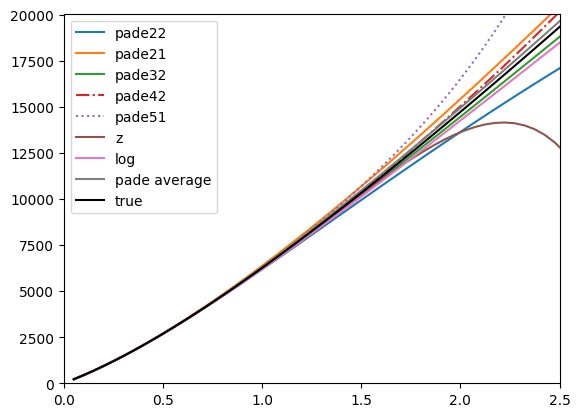

In [87]:
fig, ax = plt.subplots()

plt.plot(zs, dLpade22(zs, H0p, q0p, j0p, s0p, c0p, p0p, 0), label='pade22')
plt.plot(zs, dLpade21(zs, H0p, q0p, j0p, s0p, c0p, p0p, 0), label='pade21')
plt.plot(zs, dLpade32(zs, H0p, q0p, j0p, s0p, c0p, p0p, 0), label='pade32')
plt.plot(zs, dLpade42(zs, H0p, q0p, j0p, s0p, c0p, p0p, 0),ls='-.',label='pade42')
plt.plot(zs, dL_pade51(zs, H0p, q0p, j0p, s0p, c0p, p0p, 0),ls=':', label='pade51')
plt.plot(zs, z_series(zs, H0p, q0p, j0p, s0p, c0p, p0p, 0, 5), label='z')
plt.plot(zs, log_series(np.log(1+zs), H0p, q0p, j0p, s0p, c0p, p0p, 0, 2), label='log')
plt.plot(zs, dLpadeaverage(zs, H0p, q0p, j0p, s0p, c0p, p0p, 0), label='pade average')
plt.plot(zs,dls_true,'k', label='true')


xmax= 2.5
plt.xlim(0, xmax)
plt.ylim(0, dls_true[np.max(np.where(np.isclose(zs,xmax, atol = 0.1)==True))])


leg = ax.legend(loc="upper left")

# Minimizer for z, y, log and Pade

In [26]:
initial_guess = [70, 0.5, 1, -0.35, 3, -10, 0] # Calculated using LCDM values.
bounds = [(65, 75),  # H0 bounds
          (-1, 1),   # q0 bounds
          (None, None),  # j0 no bounds
          (None, None),  # s0 no bounds
          (None, None),  # c0 no bounds
          (None, None),  # p0 no bounds
          (-1, 1)]  # Ok bounds

def chi_square(theta,func, z, data, order):
    diff = func(z, *theta, order) - data
    return np.sum(diff*diff)

In [64]:
results_z = minimize(chi_square, initial_guess, args=(z_series, zs, dls_true, 5), bounds=bounds, method='L-BFGS-B', options={'maxiter':20000})
print(results_z.x)

[ 6.99999999e+01  5.00007972e-01  4.87198724e-01 -5.58047707e-01
  2.97569902e+00 -1.00008615e+01  2.11286718e-04]


In [66]:
log1zs = np.log(1+zs)
results_log = minimize(chi_square, initial_guess, args=(log_series, log1zs, dls_true, 5),bounds=bounds, method='L-BFGS-B', options={'maxiter':20000})
print(results_log.x)

[72.68650111 -0.45024522  0.8568043  -1.12240483  2.85232116 -9.94029851
  0.15596223]


In [29]:
log1zs = np.log(1+zs)
results_log = minimize(chi_square, initial_guess, args=(log_series, log1zs, dls_true, 5),bounds=bounds, method='L-BFGS-B', options={'maxiter':20000})
print(results_log.x)

[72.68650111 -0.45024522  0.8568043  -1.12240483  2.85232116 -9.94029851
  0.15596223]


In [30]:
results_y = minimize(chi_square, initial_guess, args=(y_series, zs, dls_true, 5), method='L-BFGS-B',bounds=bounds, options={'maxiter':20000})
print(results_y.x)

[ 70.0910178    0.99739001   4.02710692  -0.5376019    3.04098453
 -10.01939645  -1.        ]


In [80]:
results_padeav = minimize(chi_square, initial_guess, args=(dLpadeaverage, zs, dls_true, 0), method='L-BFGS-B',bounds=bounds, options={'maxiter':20000})
print(results_padeav.x)

[ 69.94774111   0.09056422  -0.15866852   0.14814718   2.87577252
 -10.           0.27266057]


In [77]:
results_pade21 = minimize(chi_square, initial_guess, args=(dLpade21, zs, dls_true, 0), method='L-BFGS-B',bounds=bounds, options={'maxiter':20000})
print(results_pade21.x)

results_pade22 = minimize(chi_square, initial_guess, args=(dLpade22, zs, dls_true, 0), method='L-BFGS-B',bounds=bounds, options={'maxiter':20000})
print(results_pade22.x)

results_pade32 = minimize(chi_square, initial_guess, args=(dLpade32, zs, dls_true, 0), method='L-BFGS-B',bounds=bounds, options={'maxiter':20000})
print(results_pade32.x)

results_pade42 = minimize(chi_square, initial_guess, args=(dLpade42, zs, dls_true, 0), method='L-BFGS-B',bounds=bounds, options={'maxiter':20000})
print(results_pade42.x)

results_pade51 = minimize(chi_square, initial_guess, args=(dLpade51, zs, dls_true, 0), method='L-BFGS-B',bounds=bounds, options={'maxiter':20000})
print(results_pade51.x)

[ 70.8614036   -0.35623806   0.47433911  -0.35         3.
 -10.          -0.26226207]
[ 7.00898588e+01 -3.15490585e-01  6.77339049e-01 -8.57908858e-02
  3.00000000e+00 -1.00000000e+01  4.48356325e-02]
[ 7.06559662e+01 -3.48288922e-01  1.08145178e+00 -6.38433341e-02
  3.02982475e+00 -1.00000000e+01  4.00051876e-01]
[69.84651119  0.14900622  0.80974915 -0.11439471  3.04315927 -9.99905794
  0.11678694]
[ 65.           0.27465594  -1.83906213   1.45782709   0.49279925
 -10.19303118  -0.59415987]


In [88]:
results_padeav = minimize(chi_square, initial_guess, args=(dLpadeaverage, zs, dls_true, 0), bounds=bounds, method = 'Powell', tol=10**-13,  options={'maxiter':150000})
print(results_padeav.x)

[ 68.3306676    0.80784505   0.71053413  -0.57031178   3.61856532
 -10.           0.54049022]


# Eis cosmography

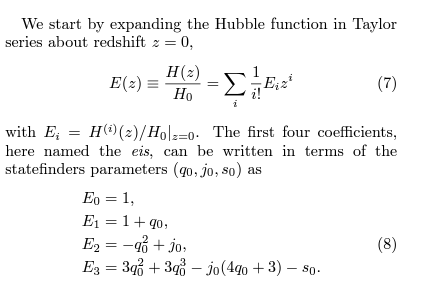   
Animesh: Note to self
Covnert asap you get the Hubble expansion

This is the expansion for EIS cosmography

Taken from paper 1606.09195



In [ ]:
from scipy import integrate
c=300000
q0=-0.55
j0=1
s0=-0.35
E0=1
E1=1+q0
E2=-q0**2+j0
E3=3*q0**2+3*q0*3-j0*(4*q0+3)-s0

zlow=0.03
zmid=0.5
zhigh= 6
def dL_EIS41(z,E0,E1,E2,E3,H0):
    dL=np.full(z.shape,np.nan)
    def func(z,E0,E1,E2,E3):
        if z_val<=zlow:
            y=1/(E0+E1*z)
        elif zlow<z_val<=zmid:
            y=1/(E0+E1*z+(E2*z**2)/2)
        elif zmid<z_val<=zhigh:
            y=1/(E0+E1*z+(E2*z**2)/2+(E3*z**3)/6)
        else:
            y = 1 / (E0 + E1 * z + (E2 * z**2) / 2 + (E3 * z**3) / 6+ (E4 * z**4) / 24)
        return y

    for  i,z_val in  np.ndenumerate(z):
        #print(z_val,integrate.quad(func,0,z_val,args=(E0,E1,E2,E3)))
        dL[i]=(1+z_val)*integrate.quad(func,0,z_val,args=(E0,E1,E2,E3),limit=100)[0]
    return (c/H0)*dL



def lkl_eis41(pars,z,y):

    x=dL_EIS41(z,*pars)
    return np.sum((y-x)**2)


def lkl_eis31(pars,z,y):

    x=dL_EIS31(z,*pars)
    return np.sum((y-x)**2)

def to_statefinders1(theta):
    H0_pop=theta[-1]
    theta=theta[:-1]
    E0=theta[0]
    E1=theta[1]
    E2=theta[2]
    q0=E1 - 1
    j0=E1**2 - 2*E1 + E2 + 1
    theta_final=[q0,j0]
    try:
            E3=theta[3]
            s0=-4*E1**3 + 12*E1**2 - 4*E1*E2 - 3*E1 + E2 - E3 - 5
            theta_final.append(s0)
    except:
        pass
    theta_final.append(H0_pop)
    return theta_final

q0=-0.55
j0=1
s0=-0.35
E0=1
E1=1+q0
E2=-q0**2+j0
E3=3*q0**2+3*q0**3-j0*(4*q0+3)-s0
prior1=[E0,E1,E2,E3,75]
#MLE1 = minimize(lkl_eis41,prior1, method = 'Powell', tol=10**-14, args=(zs, dls_true), options={'maxiter':150000})
MLE2 = minimize(lkl_eis41,prior1, method = 'Powell', tol=10**-12, args=(zs, dls_true), options={'maxiter':150000})

#MLE3 = minimize(lkl_eis41,prior1, method = 'trust-constr', tol=10**-14, args=(zs, dls_true), options={'maxiter':150000})
#prior2=[E0,E1,E2,75]
#MLE2 = minimize(lkl_eis31,prior2, method = 'Powell',args=(zs, dls_true), tol=10**-12,  options={'maxiter':150000})
print(MLE2)

/tmp/ipykernel_8407/2876868533.py:29: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  dL[i]=(1+z_val)*integrate.quad(func,0,z_val,args=(E0,E1,E2,E3),limit=100)[0]
/tmp/ipykernel_8407/2876868533.py:29: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  dL[i]=(1+z_val)*integrate.quad(func,0,z_val,args=(E0,E1,E2,E3),limit=100)[0]
/tmp/ipykernel_8407/2876868533.py:29: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  dL[i]=(1+z_val)*integrate.quad(func,0,z_val,args=(E0,E1,E2,E3),limit=100)[0]


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 17.390465862845243
       x: [ 9.821e-01  4.534e-01  6.737e-01 -2.421e-01  7.507e+01]
     nit: 20
   direc: [[ 6.947e-06 -1.253e-03 ... -6.688e-03  8.816e-03]
           [ 1.290e-06  4.497e-06 ... -1.834e-05 -1.555e-04]
           ...
           [ 1.398e-03  5.333e-03 ... -1.434e-02 -2.086e-01]
           [ 2.259e-05 -4.700e-04 ... -2.992e-03  1.900e-03]]
    nfev: 2791


In [ ]:
dL_EIS41(np.array([1.2]),E0,E1,E2,E3,H0)
print(to_statefinders1(MLE2.x))
MLE2.x
E3=3*q0**2+3*q0**3-j0*(4*q0+3)-s0
E3



eis_res41=to_statefinders1(MLE2.x)
#eis_res42=to_statefinders1(MLE3.x)
#eis_res3=to_statefinders1(MLE2.x)

print(eis_res41)
[E0,E1,E2,E3,73.6]
zs

[-0.5465791938373383, 0.9724784429506348, -4.57218947780826, 75.06722422104066]
[-0.5465791938373383, 0.9724784429506348, -4.57218947780826, 75.06722422104066]


array([0.01614141, 0.03128283, 0.04642424, 0.06156566, 0.07670707,
       0.09184848, 0.1069899 , 0.12213131, 0.13727273, 0.15241414,
       0.16755556, 0.18269697, 0.19783838, 0.2129798 , 0.22812121,
       0.24326263, 0.25840404, 0.27354545, 0.28868687, 0.30382828,
       0.3189697 , 0.33411111, 0.34925253, 0.36439394, 0.37953535,
       0.39467677, 0.40981818, 0.4249596 , 0.44010101, 0.45524242,
       0.47038384, 0.48552525, 0.50066667, 0.51580808, 0.53094949,
       0.54609091, 0.56123232, 0.57637374, 0.59151515, 0.60665657,
       0.62179798, 0.63693939, 0.65208081, 0.66722222, 0.68236364,
       0.69750505, 0.71264646, 0.72778788, 0.74292929, 0.75807071,
       0.77321212, 0.78835354, 0.80349495, 0.81863636, 0.83377778,
       0.84891919, 0.86406061, 0.87920202, 0.89434343, 0.90948485,
       0.92462626, 0.93976768, 0.95490909, 0.97005051, 0.98519192,
       1.00033333, 1.01547475, 1.03061616, 1.04575758, 1.06089899,
       1.0760404 , 1.09118182, 1.10632323, 1.12146465, 1.13660